In [1]:
import requests
import time
import json
import datetime
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
BASE = "https://dashboard.elering.ee/api"
PARAMS = {
    "start": "2026-01-01T00:00:00.000Z",
    "end":   "2026-01-01T02:00:00.000Z"  # kun 2 timer — lille response
}

endpoints = {
    "system":               "/system",
}

for name, path in endpoints.items():
    try:
        r = requests.get(BASE + path, params=PARAMS)
        data = r.json()
        
        # Hent første datapunkt og print feltnavne
        if isinstance(data, dict) and "data" in data:
            items = data["data"]
            if isinstance(items, list) and len(items) > 0:
                first = items[0]
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Antal datapunkter: {len(items)}")
                print(f"   Felter: {list(first.keys()) if isinstance(first, dict) else type(first)}")
                print(f"   Første række: {first}")
            elif isinstance(items, dict):
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Felter: {list(items.keys())}")
                print(f"   Data: {items}")
        else:
            print(f"\n{'='*50}")
            print(f" {name} ({path})")
            print(f"   Rå svar: {str(data)[:200]}")
            
    except Exception as e:
        print(f"\n {name}: {e}")


 system (/system)
   Antal datapunkter: 25
   Felter: ['timestamp', 'production', 'consumption', 'losses', 'frequency', 'system_balance', 'ac_balance', 'production_renewable', 'solar_energy_production']
   Første række: {'timestamp': 1767225600, 'production': 264.18, 'consumption': 1047.28, 'losses': None, 'frequency': 49.96, 'system_balance': -783.1, 'ac_balance': -131.21, 'production_renewable': 76.68, 'solar_energy_production': 4.3}


## Importing all demand data of Januaries 2019-2026

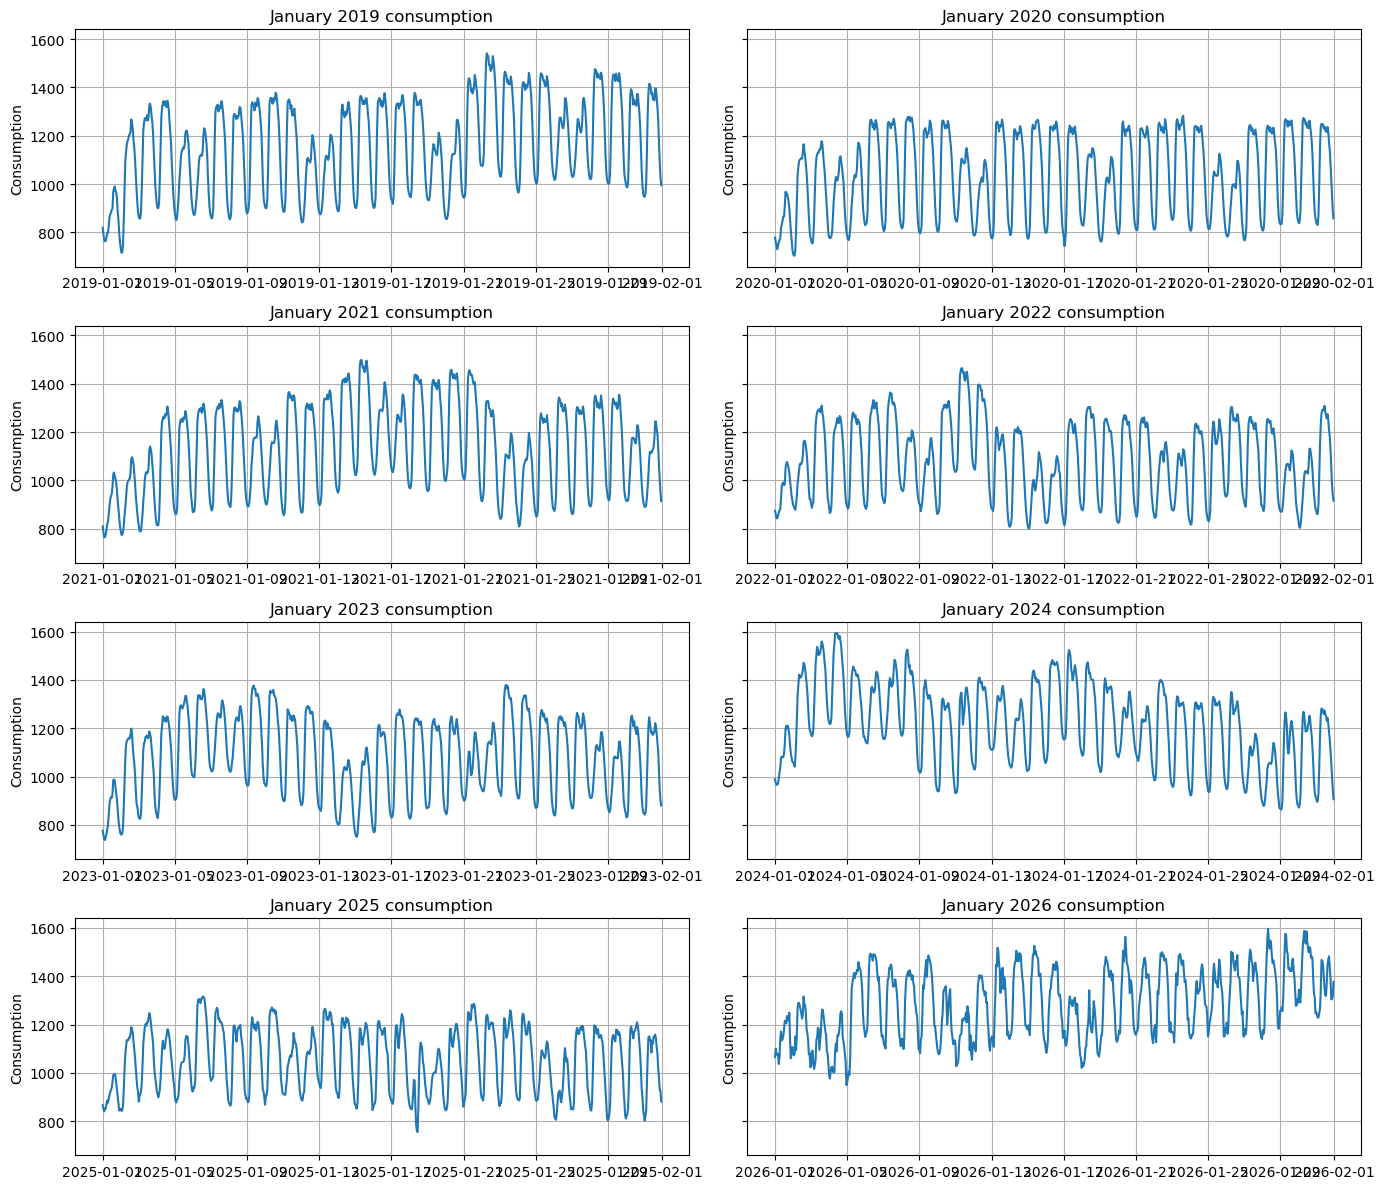

In [26]:
def fetch_january_demand(year):
    response = requests.get(
        "https://dashboard.elering.ee/api/system",
        params={
            "start": f"{year}-01-01T00:00:00.000Z",
            "end":   f"{year}-01-31T23:59:59.000Z"
        }
    )

    data = response.json()
    df = pd.DataFrame(data["data"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
    df = df.set_index("timestamp")

    demand = df["consumption"].dropna()

    # Fix known bad 2019 values
    if year == 2019:
        demand.loc["2019-01-03 11:40:00"] = demand.loc["2019-01-03 11:35:00"]
        demand.loc["2019-01-03 11:45:00"] = demand.loc["2019-01-03 11:50:00"]

    demand_hourly = demand.resample("h").mean().dropna()
    return demand_hourly


demand_series = {
    year: fetch_january_demand(year)
    for year in range(2019, 2027)
}

# Optional: keep your old variable names so later code still works
for year, series in demand_series.items():
    globals()[f"demand_jan{year}_hourly"] = series

# Plot all Januaries
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for ax, (year, series) in zip(axes, demand_series.items()):
    ax.plot(series.index, series.values)
    ax.set_title(f"January {year} consumption")
    ax.set_ylabel("Consumption")
    ax.grid(True)

for ax in axes[len(demand_series):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
def plot_acf_pacf(series, title, lags=168):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF: {title}")
    axes[0].grid(True)

    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: {title}")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

### Plotting ACF's and PACF's to determine SARIMA model order

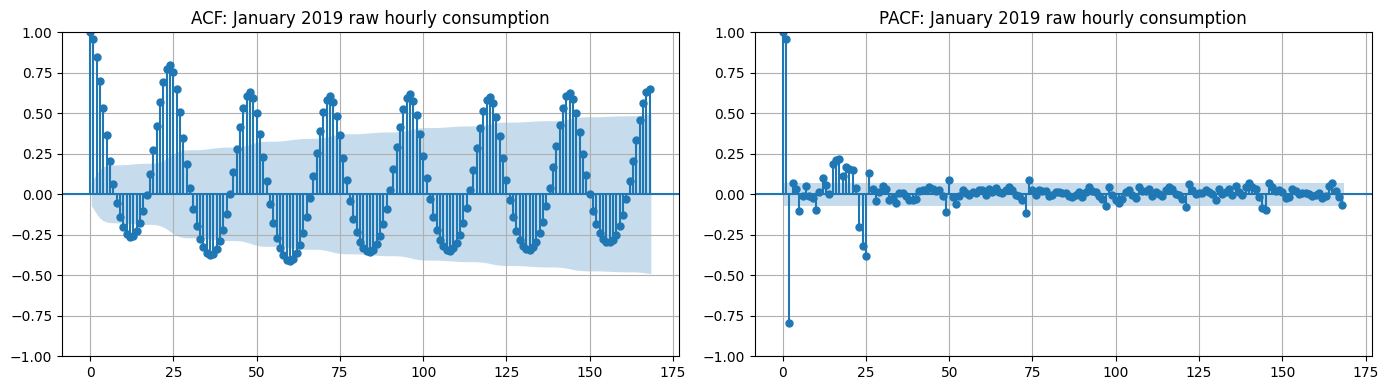

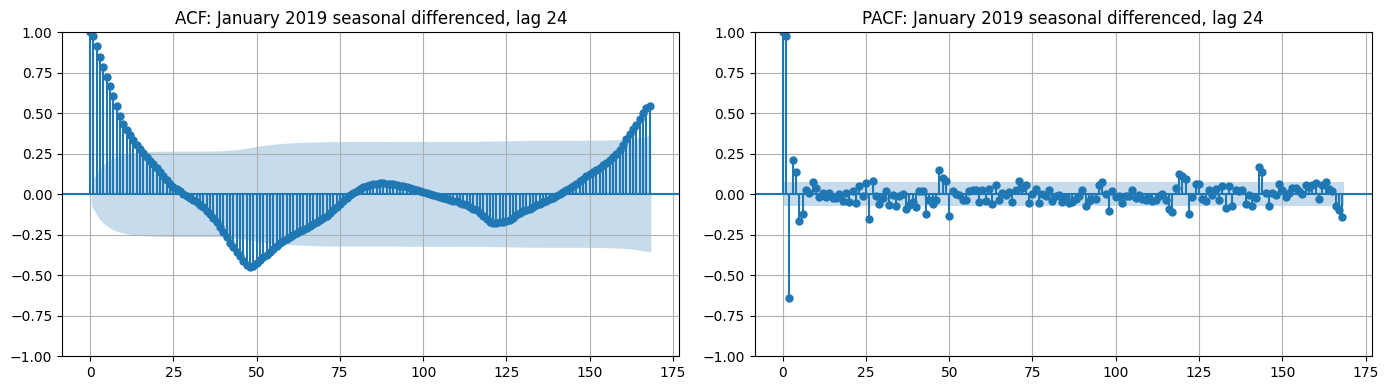

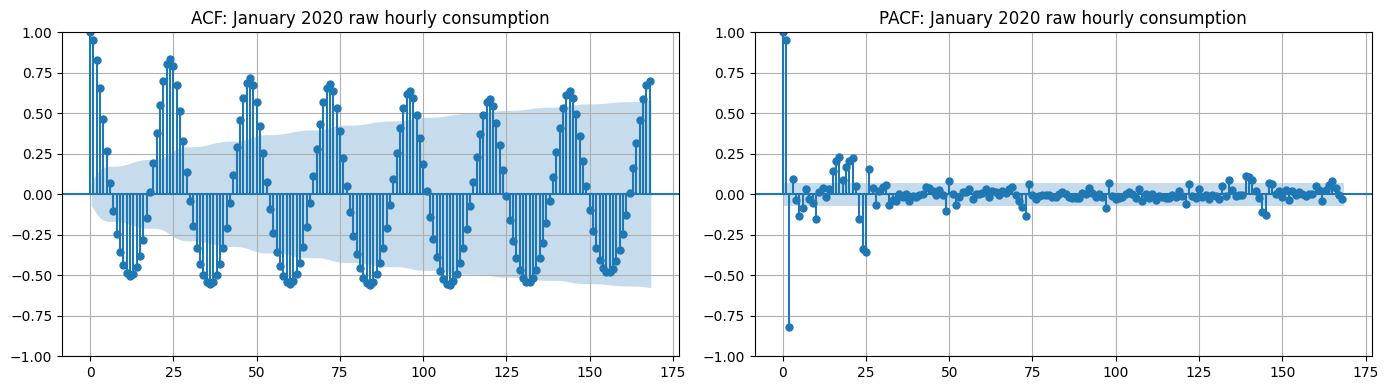

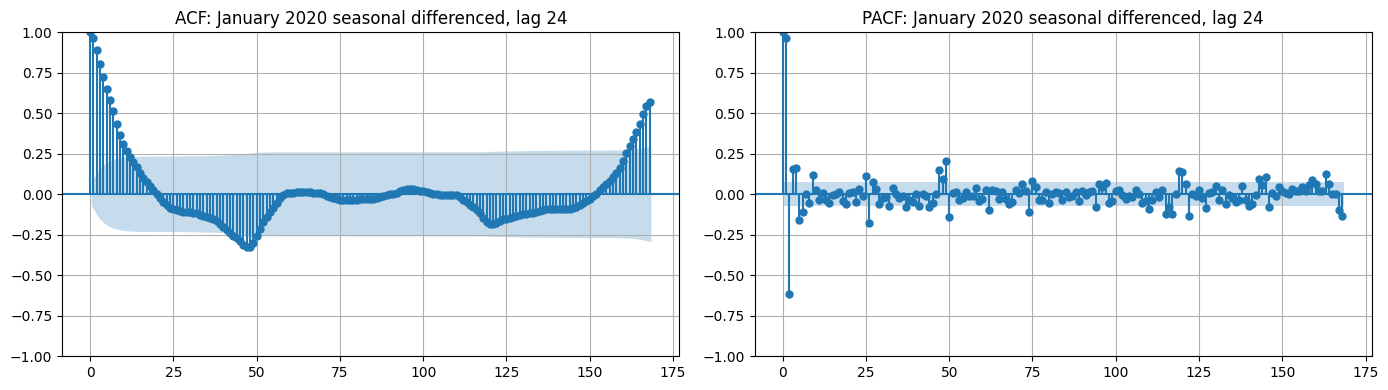

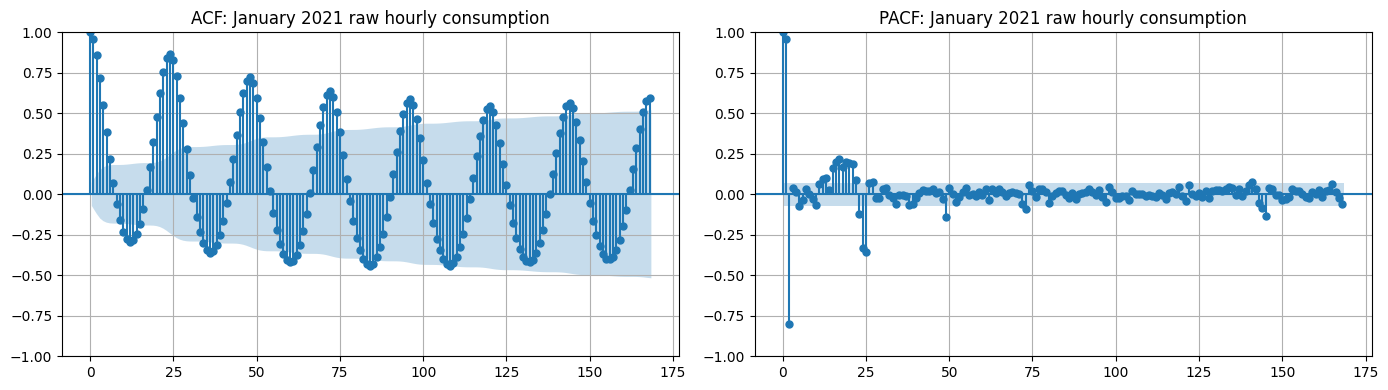

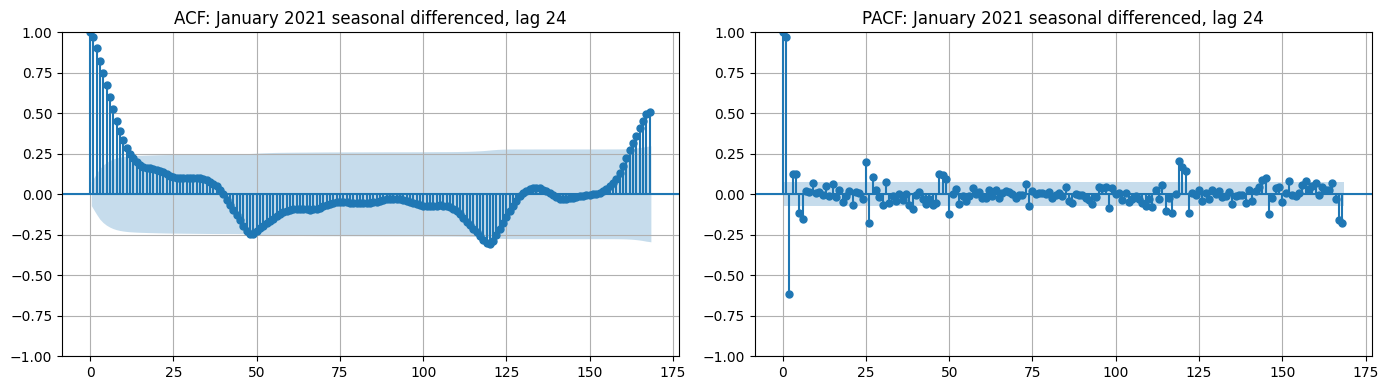

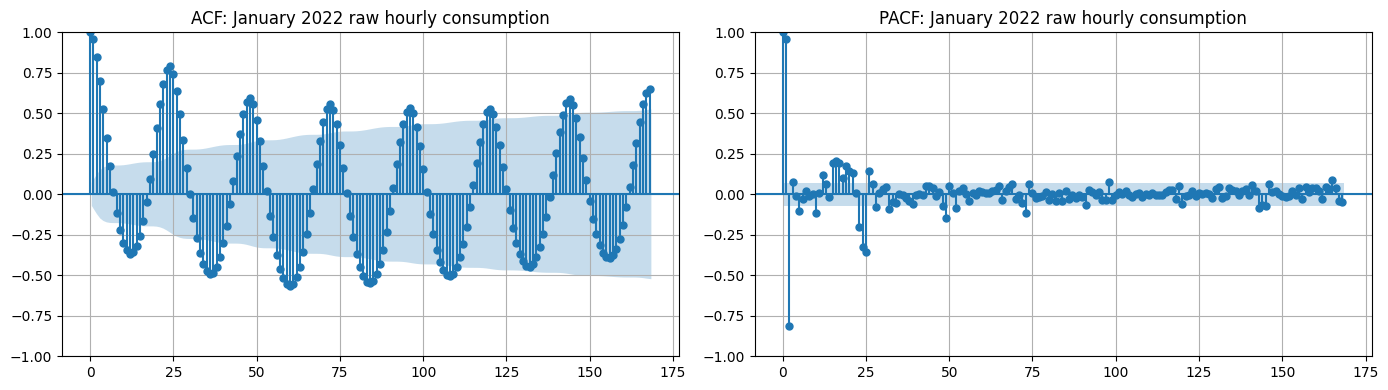

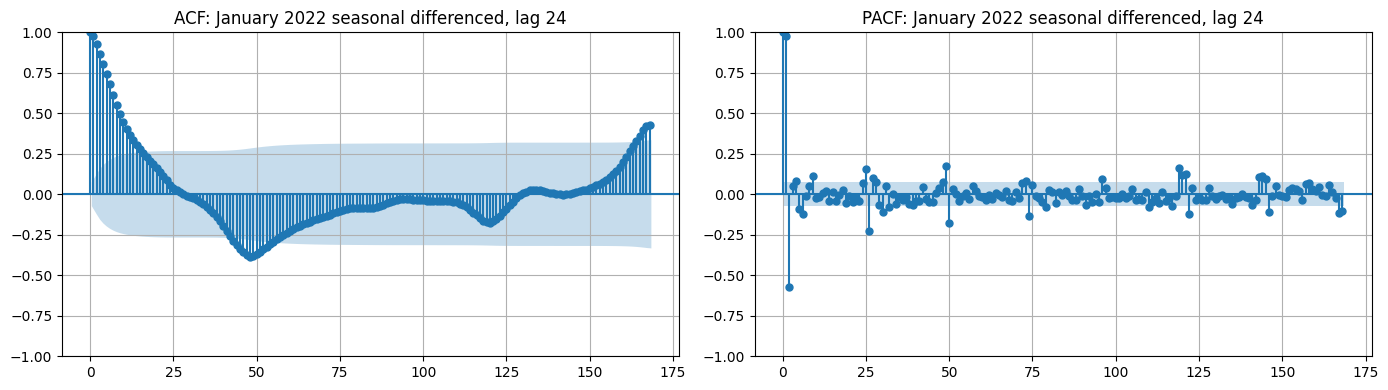

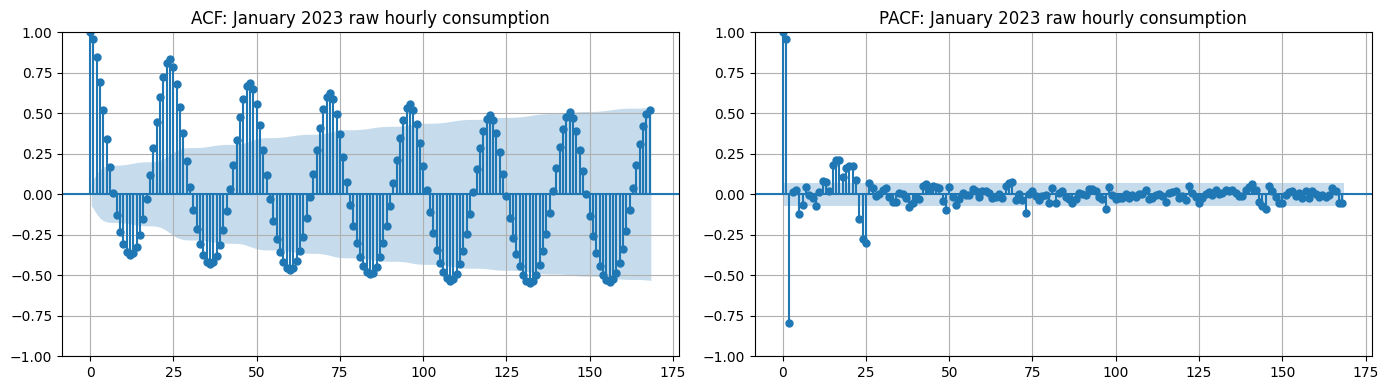

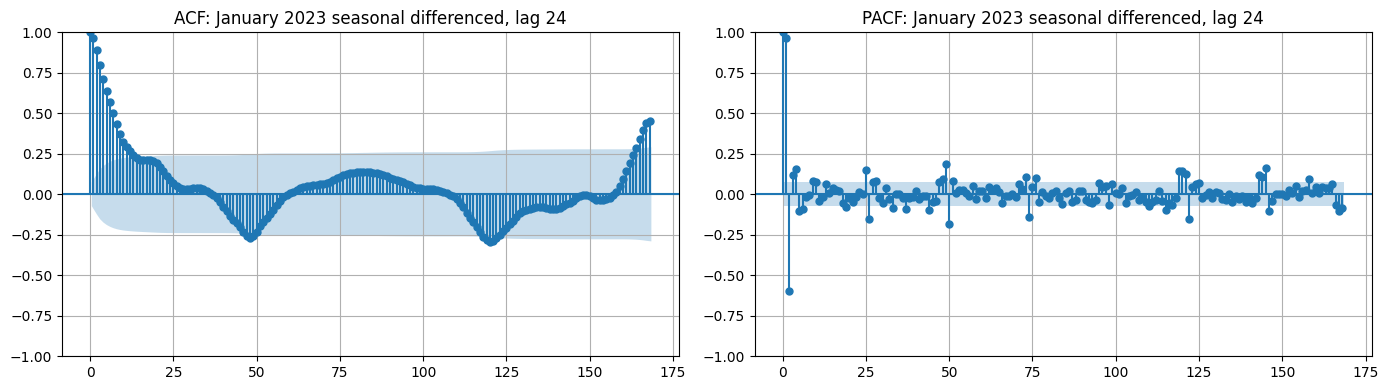

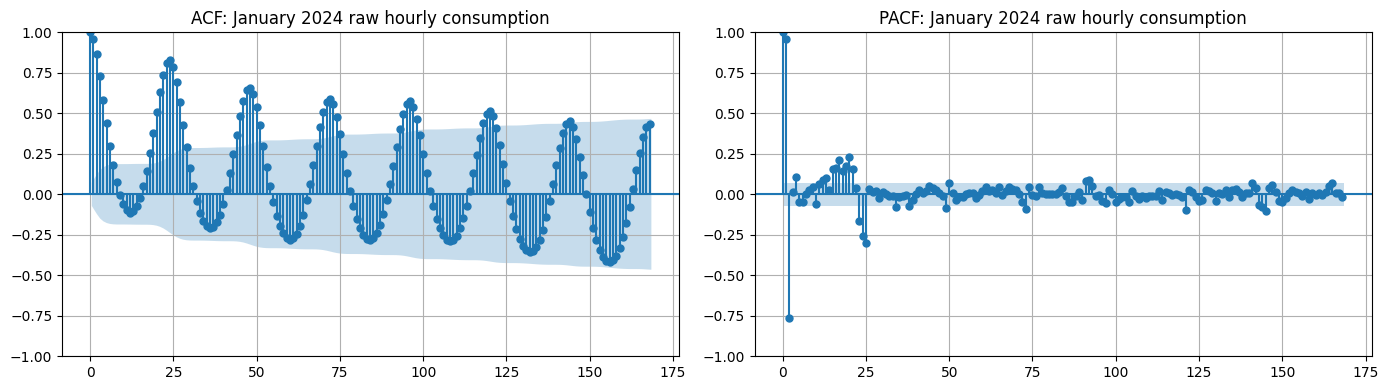

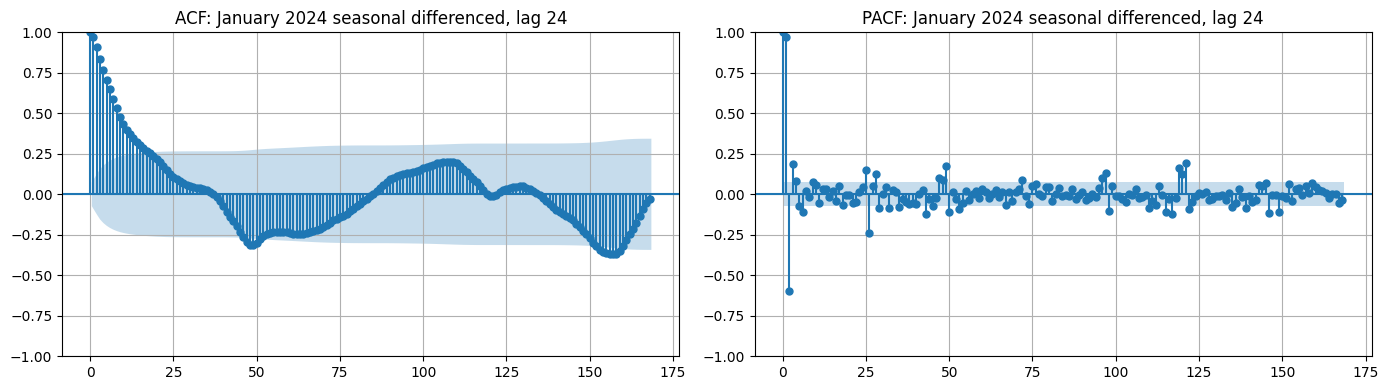

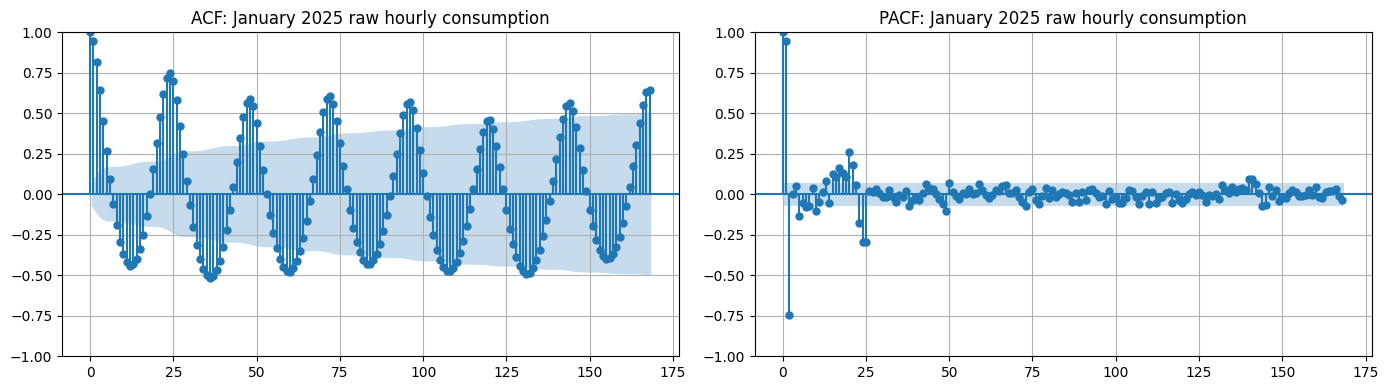

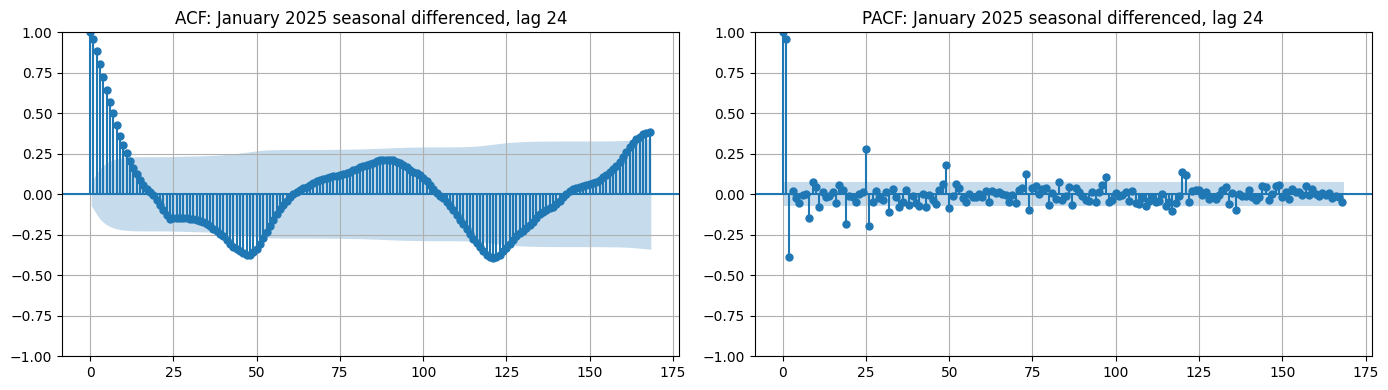

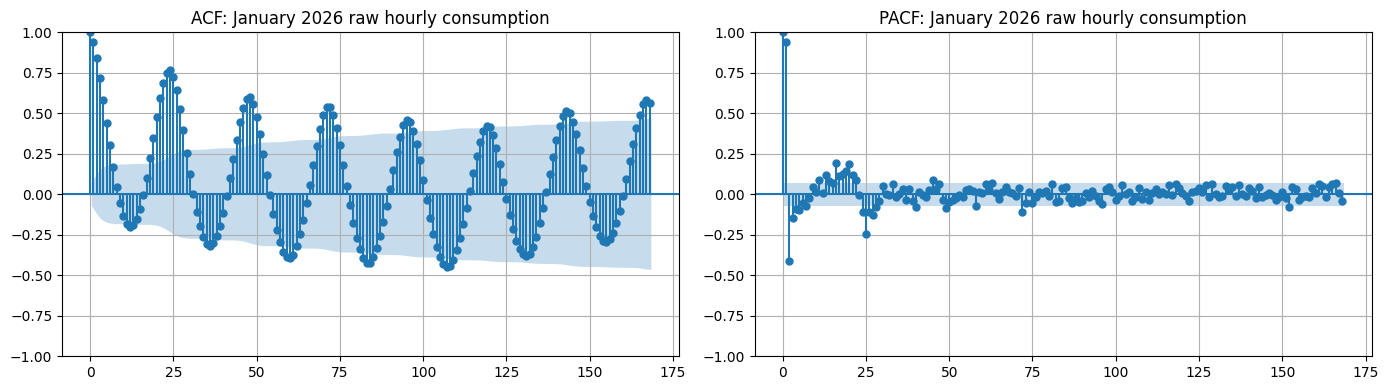

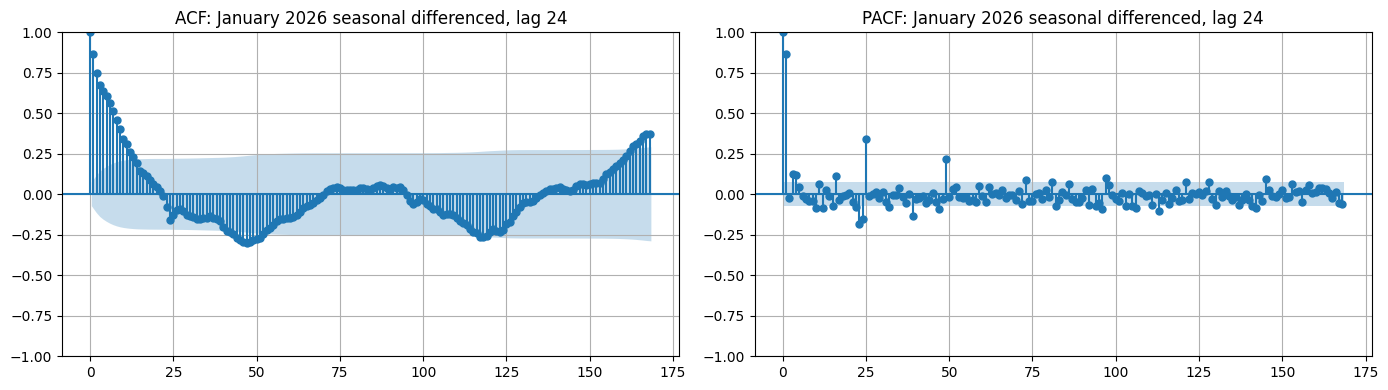

In [235]:
for year, y in demand_series.items():
    plot_acf_pacf(y, f"January {year} raw hourly consumption", lags=168)

    y_sdiff = y.diff(24)
    plot_acf_pacf(y_sdiff, f"January {year} seasonal differenced, lag 24", lags=168)

### Determining best model order

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
import numpy as np
import warnings
from IPython.display import display

# -----------------------------
# 2. Define candidate SARIMA models
# -----------------------------
candidate_models = [
    ((2, 0, 2), (1, 1, 1, 24)),
    ((2, 0, 2), (1, 0, 1, 24)),
    ((3, 0, 2), (1, 1, 1, 24)),
]

# Choose ranking metric
rank_metric = "AIC"   # use "BIC" if you prefer simpler models

# -----------------------------
# 3. Fit models year by year
# -----------------------------
all_results = []

for year, y in demand_series.items():

    y = y.dropna()

    yearly_results = []

    for model_id, (order, seasonal_order) in enumerate(candidate_models):

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fit = model.fit(disp=False)

            lb = acorr_ljungbox(
                fit.resid.dropna(),
                lags=[24],
                return_df=True
            )

            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fit.aic,
                "BIC": fit.bic,
                "Ljung-Box p-value lag 24": lb.loc[24, "lb_pvalue"],
                "converged": fit.mle_retvals.get("converged", None)
            })

        except Exception as e:
            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": np.nan,
                "BIC": np.nan,
                "Ljung-Box p-value lag 24": np.nan,
                "converged": False,
                "error": str(e)
            })

    yearly_table = pd.DataFrame(yearly_results)

    # Sort by chosen ranking metric
    yearly_table = yearly_table.sort_values(rank_metric, ascending=True).reset_index(drop=True)

    # Score: best = 5, second = 4, ..., fifth = 1
    yearly_table["score"] = 0
    yearly_table.loc[:4, "score"] = list(range(3, 0, -1))

    print(f"\nModel comparison for January {year}, ranked by {rank_metric}")
    display(yearly_table)

    all_results.append(yearly_table)

# -----------------------------
# 4. Combine all yearly results
# -----------------------------
all_results_df = pd.concat(all_results, ignore_index=True)

# -----------------------------
# 5. Total score across all years
# -----------------------------
score_summary = (
    all_results_df
    .groupby(["order", "seasonal_order"], as_index=False)
    .agg(
        total_score=("score", "sum"),
        mean_score=("score", "mean"),
        mean_AIC=("AIC", "mean"),
        mean_BIC=("BIC", "mean"),
        median_AIC=("AIC", "median"),
        median_BIC=("BIC", "median"),
        first_places=("score", lambda x: (x == 3).sum()),
        years_tested=("score", "count")
    )
    .sort_values(
        ["total_score", "first_places", "mean_AIC"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

print("\nOverall model score across all years")
display(score_summary)

# -----------------------------
# 6. Extract the overall best model
# -----------------------------
best_overall_model = score_summary.iloc[0]

print("Best overall model:")
print(f"order = {best_overall_model['order']}")
print(f"seasonal_order = {best_overall_model['seasonal_order']}")
print(f"total_score = {best_overall_model['total_score']}")
print(f"first_places = {best_overall_model['first_places']}")
print(f"mean_AIC = {best_overall_model['mean_AIC']:.2f}")
print(f"mean_BIC = {best_overall_model['mean_BIC']:.2f}")


Model comparison for January 2019, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2019,2,"(3, 0, 2)","(1, 1, 1, 24)",5602.762782,5639.091022,1.763157e-31,True,3
1,2019,0,"(2, 0, 2)","(1, 1, 1, 24)",5609.670798,5641.458008,2.527559e-43,True,2
2,2019,1,"(2, 0, 2)","(1, 0, 1, 24)",6042.382086,6074.407617,3.345142e-65,False,1



Model comparison for January 2020, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2020,2,"(3, 0, 2)","(1, 1, 1, 24)",5607.124483,5643.452723,9.330519e-38,True,3
1,2020,0,"(2, 0, 2)","(1, 1, 1, 24)",5607.417590,5639.204800,8.882372e-72,True,2
2,2020,1,"(2, 0, 2)","(1, 0, 1, 24)",5872.910095,5904.935626,1.021455e-20,True,1



Model comparison for January 2021, ranked by AIC


...


Model comparison for January 2025, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2025,0,"(2, 0, 2)","(1, 1, 1, 24)",6111.391155,6143.168256,1.861172e-88,True,3
1,2025,2,"(3, 0, 2)","(1, 1, 1, 24)",6188.303427,6224.620114,3.552461e-19,False,2
2,2025,1,"(2, 0, 2)","(1, 0, 1, 24)",6335.499301,6367.515062,1.034331e-17,True,1



Overall model score across all years


,order,seasonal_order,total_score,mean_score,mean_AIC,mean_BIC,median_AIC,median_BIC,first_places,years_tested
0,"(3, 0, 2)","(1, 1, 1, 24)",19,2.714286,5688.298848,5724.625437,5602.762782,5639.091022,5,7
1,"(2, 0, 2)","(1, 1, 1, 24)",16,2.285714,5679.997397,5711.783163,5607.417590,5639.204800,2,7
2,"(2, 0, 2)","(1, 0, 1, 24)",7,1.000000,5974.388162,6006.412297,5891.149979,5923.175510,0,7


Best overall model:
order = (3, 0, 2)
seasonal_order = (1, 1, 1, 24)
total_score = 19
first_places = 5
mean_AIC = 5688.30
mean_BIC = 5724.63


## Fetch weather data

In [4]:
def fetch_weather_from_openmeteo(lat, lon, start_date, end_date, location_name=""):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,wind_speed_10m",
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "timezone": "UTC"
    }

    print(f"Fetching weather: {location_name}")

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    hourly = data["hourly"]

    df = pd.DataFrame({
        "timestamp": pd.to_datetime(hourly["time"]),
        "temperature": hourly["temperature_2m"],
        "wind_speed": hourly["wind_speed_10m"]
    })

    df = df.set_index("timestamp")
    return df


weather_series = {}

for year in range(2019, 2027):
    weather_series[year] = fetch_weather_from_openmeteo(
        lat=59.437,
        lon=24.753,
        start_date=f"{year}-01-01",
        end_date=f"{year}-01-31",
        location_name=f"Estonia January {year}"
    )

Fetching weather: Estonia January 2019
Fetching weather: Estonia January 2020
Fetching weather: Estonia January 2021
Fetching weather: Estonia January 2022
Fetching weather: Estonia January 2023
Fetching weather: Estonia January 2024
Fetching weather: Estonia January 2025
Fetching weather: Estonia January 2026


In [5]:
combined_dfs = {}

for year in range(2019, 2026):
    demand = demand_series[year].rename("consumption")
    weather = weather_series[year][["temperature", "wind_speed"]]

    df = pd.concat([demand, weather], axis=1).dropna()

    df["weekend"] = (df.index.dayofweek >= 5).astype(int)

    combined_dfs[year] = df

    print(year, df.shape, df.index.min(), df.index.max())

2019 (744, 4) 2019-01-01 00:00:00 2019-01-31 23:00:00
2020 (744, 4) 2020-01-01 00:00:00 2020-01-31 23:00:00
2021 (744, 4) 2021-01-01 00:00:00 2021-01-31 23:00:00
2022 (744, 4) 2022-01-01 00:00:00 2022-01-31 23:00:00
2023 (744, 4) 2023-01-01 00:00:00 2023-01-31 23:00:00
2024 (744, 4) 2024-01-01 00:00:00 2024-01-31 23:00:00
2025 (743, 4) 2025-01-01 00:00:00 2025-01-31 23:00:00


In [13]:
for year, df in combined_dfs.items():
    print(year, df.shape, df.index.min(), df.index.max())
    print(df.isna().sum())

2019 (744, 4) 2019-01-01 00:00:00 2019-01-31 23:00:00
consumption    0
temperature    0
wind_speed     0
weekend        0
dtype: int64
2020 (744, 4) 2020-01-01 00:00:00 2020-01-31 23:00:00
consumption    0
temperature    0
wind_speed     0
weekend        0
dtype: int64
2021 (744, 4) 2021-01-01 00:00:00 2021-01-31 23:00:00
consumption    0
temperature    0
wind_speed     0
weekend        0
dtype: int64
2022 (744, 4) 2022-01-01 00:00:00 2022-01-31 23:00:00
consumption    0
temperature    0
wind_speed     0
weekend        0
dtype: int64
2023 (744, 4) 2023-01-01 00:00:00 2023-01-31 23:00:00
consumption    0
temperature    0
wind_speed     0
weekend        0
dtype: int64
2024 (744, 4) 2024-01-01 00:00:00 2024-01-31 23:00:00
consumption    0
temperature    0
wind_speed     0
weekend        0
dtype: int64
2025 (743, 4) 2025-01-01 00:00:00 2025-01-31 23:00:00
consumption    0
temperature    0
wind_speed     0
weekend        0
dtype: int64


In [47]:
features = ["temperature", "wind_speed", "weekend"]

order = (3, 0, 2)
seasonal_order = (1, 1, 1, 24)

fitted_models = {}

for year, df in combined_dfs.items():
    y = df["consumption"]
    X = df[features]

    model = SARIMAX(
        y,
        exog=X,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)
    fitted_models[year] = fit

    print(f"{year}: AIC = {fit.aic:.2f}, BIC = {fit.bic:.2f}")

/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2019: AIC = 6308.47, BIC = 6358.42


/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2020: AIC = 6047.79, BIC = 6097.74


/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

2023: AIC = 5965.14, BIC = 6015.09


/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2024: AIC = 5880.67, BIC = 5930.62


/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2025: AIC = 6289.71, BIC = 6339.65


In [19]:
coef_rows = []

for year, fit in fitted_models.items():
    for name in fit.params.index:
        coef_rows.append({
            "year": year,
            "parameter": name,
            "estimate": fit.params[name],
            "p_value": fit.pvalues[name]
        })

coef_table = pd.DataFrame(coef_rows)

display(coef_table[coef_table["year"] == 2019])
display(coef_table[coef_table["year"] == 2020])
display(coef_table[coef_table["year"] == 2021])
display(coef_table[coef_table["year"] == 2022])
display(coef_table[coef_table["year"] == 2023])
display(coef_table[coef_table["year"] == 2024])
display(coef_table[coef_table["year"] == 2025])

,year,parameter,estimate,p_value
0,2019,temperature,4.893666,3.782936e-04
1,2019,wind_speed,0.122644,8.032985e-01
2,2019,weekend,-109.655892,2.683555e-194
3,2019,ar.L1,0.602800,7.576096e-06
4,2019,ar.L2,0.296617,2.244854e-02
5,2019,ma.L1,0.773494,1.607779e-09
6,2019,ma.L2,0.308835,2.889547e-19
7,2019,ar.S.L24,0.154399,9.261724e-08
8,2019,ma.S.L24,-0.887378,1.214225e-259
9,2019,sigma2,393.371491,2.248675e-56


,year,parameter,estimate,p_value
10,2020,temperature,-3.177866,6.644786e-02
11,2020,wind_speed,1.953735,3.484423e-07
12,2020,weekend,-82.726683,2.838965e-192
13,2020,ar.L1,1.586635,2.020291e-31
14,2020,ar.L2,-0.656481,3.043973e-08
15,2020,ma.L1,-0.199766,1.517574e-01
16,2020,ma.L2,-0.127397,2.079806e-01
17,2020,ar.S.L24,0.238609,2.264161e-12
18,2020,ma.S.L24,-0.910154,5.452718e-93
19,2020,sigma2,341.026581,8.726622e-48


,year,parameter,estimate,p_value
20,2021,temperature,10.732163,7.587830e-15
21,2021,wind_speed,-0.086235,8.485170e-01
22,2021,weekend,-40.775488,3.299880e-84
23,2021,ar.L1,1.269269,3.333258e-79
24,2021,ar.L2,-0.312685,5.778496e-06
25,2021,ma.L1,0.315957,7.933166e-06
26,2021,ma.L2,0.243759,2.313667e-06
27,2021,ar.S.L24,0.264942,4.719045e-16
28,2021,ma.S.L24,-0.879449,6.850385e-222
29,2021,sigma2,227.444697,3.399811e-95


,year,parameter,estimate,p_value
30,2022,temperature,-5.240913,1.449682e-07
31,2022,wind_speed,0.134668,7.416058e-01
32,2022,weekend,-112.387506,8.077830e-192
33,2022,ar.L1,1.167441,2.782625e-08
34,2022,ar.L2,-0.288743,1.204333e-01
35,2022,ma.L1,0.073965,7.311805e-01
36,2022,ma.L2,0.120098,1.895798e-01
37,2022,ar.S.L24,0.191321,7.554469e-11
38,2022,ma.S.L24,-1.042250,4.387474e-108
39,2022,sigma2,337.261342,4.777501e-33


,year,parameter,estimate,p_value
40,2023,temperature,5.483566,2.221251e-07
41,2023,wind_speed,-0.310370,4.423463e-01
42,2023,weekend,-75.100636,1.270928e-190
43,2023,ar.L1,1.093909,1.180989e-25
44,2023,ar.L2,-0.156702,1.234655e-01
45,2023,ma.L1,0.352168,5.921871e-04
46,2023,ma.L2,0.240748,1.735502e-04
47,2023,ar.S.L24,0.189671,1.500044e-08
48,2023,ma.S.L24,-0.947318,2.006698e-127
49,2023,sigma2,269.545321,2.075138e-50


,year,parameter,estimate,p_value
50,2024,temperature,-6.584565,3.513204e-22
51,2024,wind_speed,-0.357403,3.269156e-01
52,2024,weekend,-74.301702,2.057587e-257
53,2024,ar.L1,1.081467,3.051833e-23
54,2024,ar.L2,-0.168525,1.104970e-01
55,2024,ma.L1,0.394396,2.783177e-04
56,2024,ma.L2,0.191106,2.038326e-03
57,2024,ar.S.L24,0.178641,2.272114e-07
58,2024,ma.S.L24,-0.926361,3.261384e-169
59,2024,sigma2,237.665785,2.997086e-80


,year,parameter,estimate,p_value
60,2025,temperature,2.531708,2.162941e-01
61,2025,wind_speed,0.285382,5.635139e-01
62,2025,weekend,-88.300312,2.565450e-196
63,2025,ar.L1,1.242799,2.649017e-11
64,2025,ar.L2,-0.359470,3.011542e-02
65,2025,ma.L1,0.009148,9.615671e-01
66,2025,ma.L2,0.076035,3.669512e-01
67,2025,ar.S.L24,0.135758,3.301717e-05
68,2025,ma.S.L24,-0.887909,1.500642e-204
69,2025,sigma2,456.387349,5.782617e-100


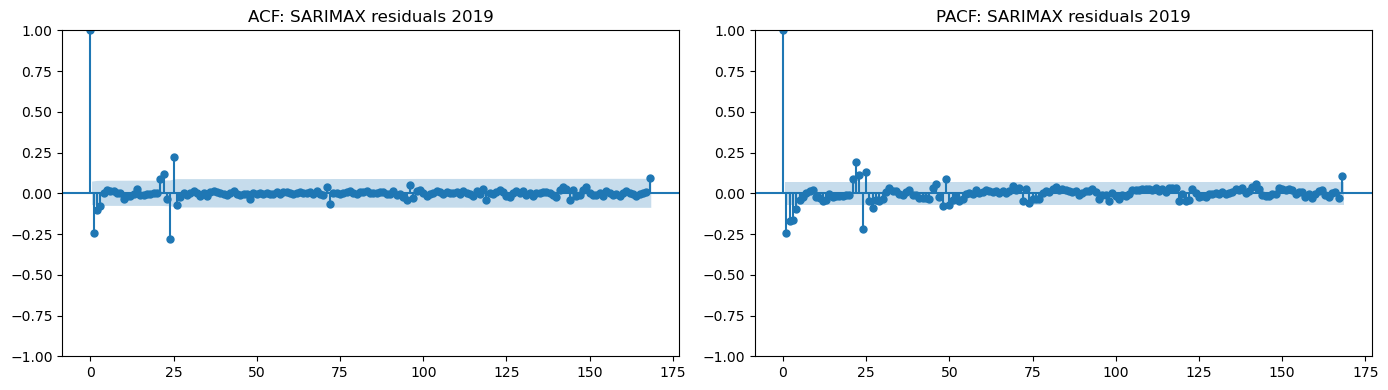

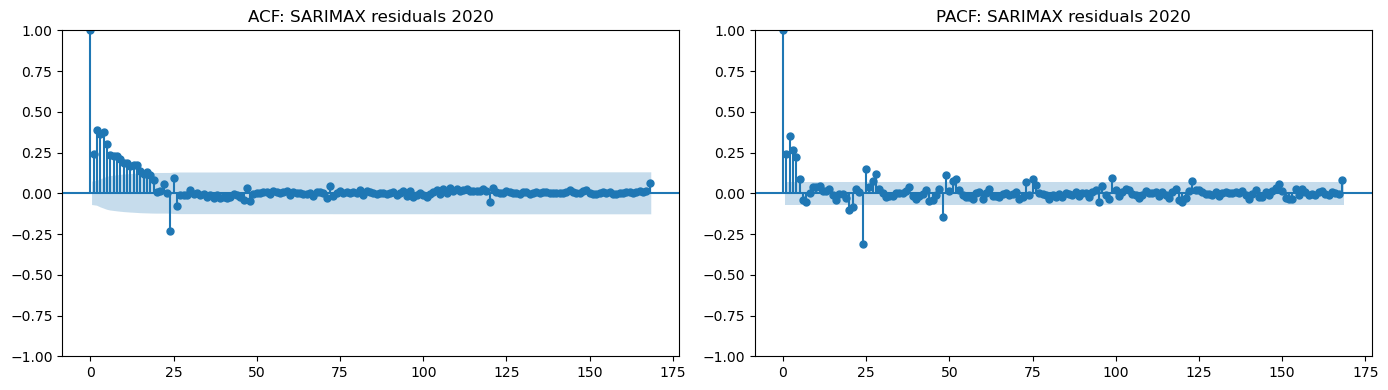

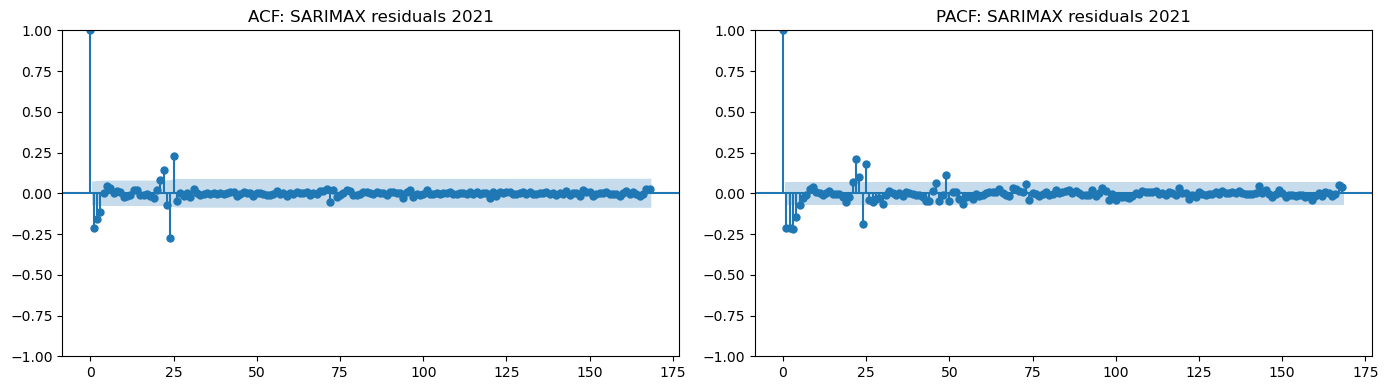

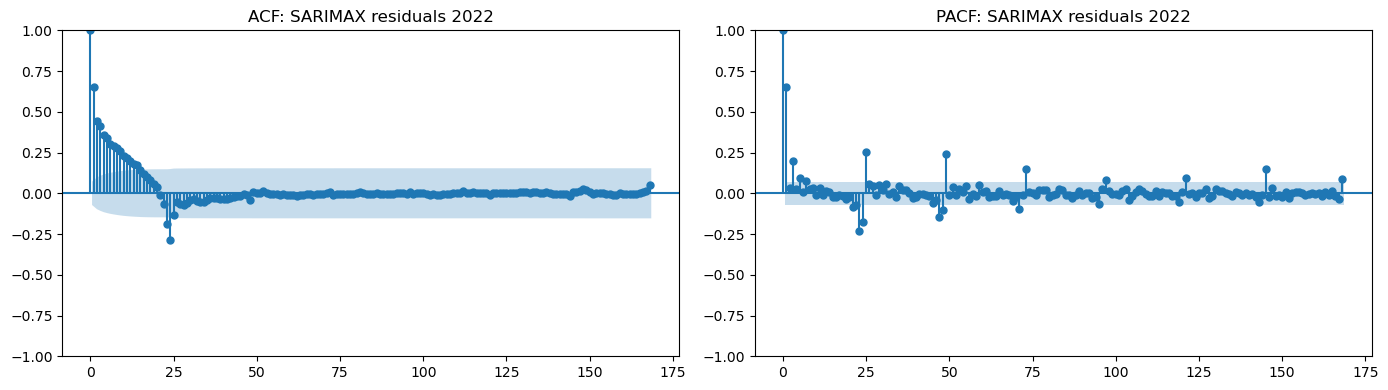

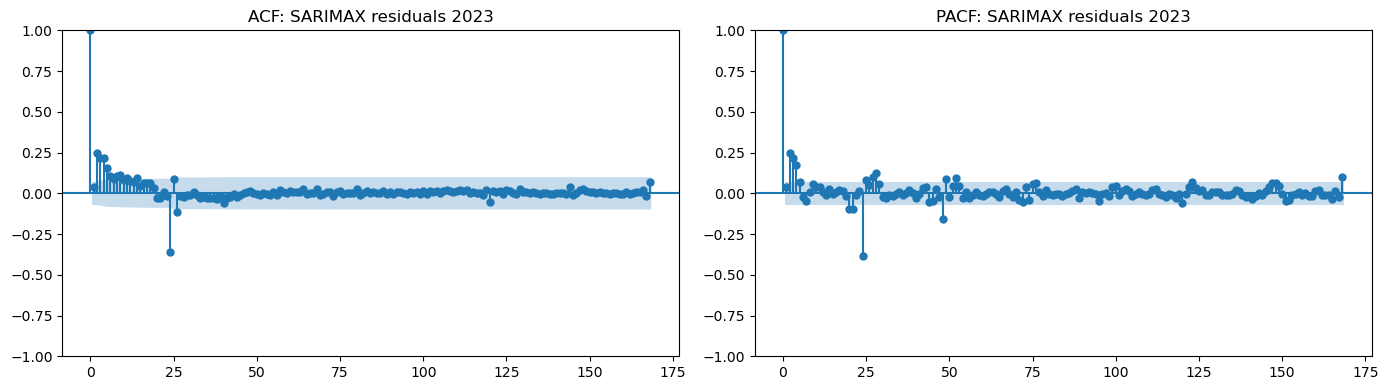

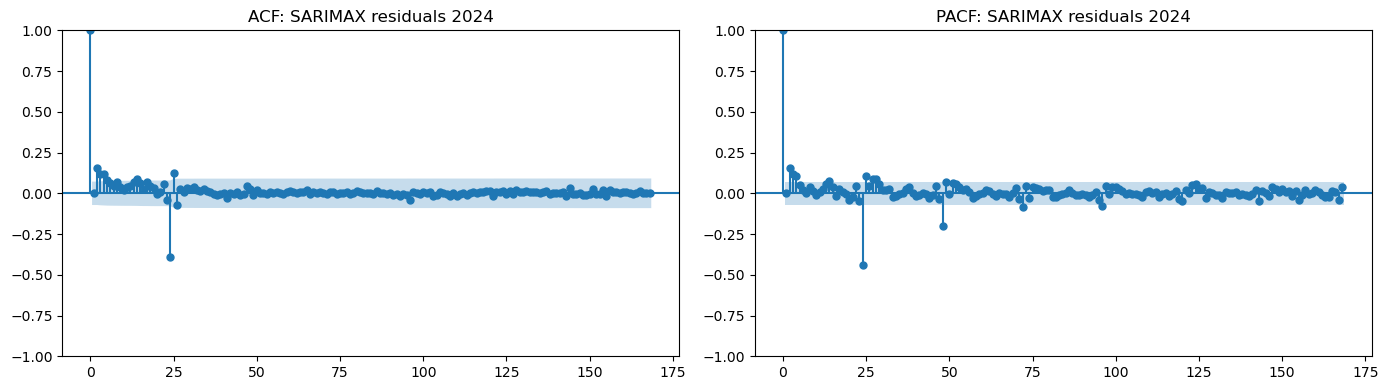

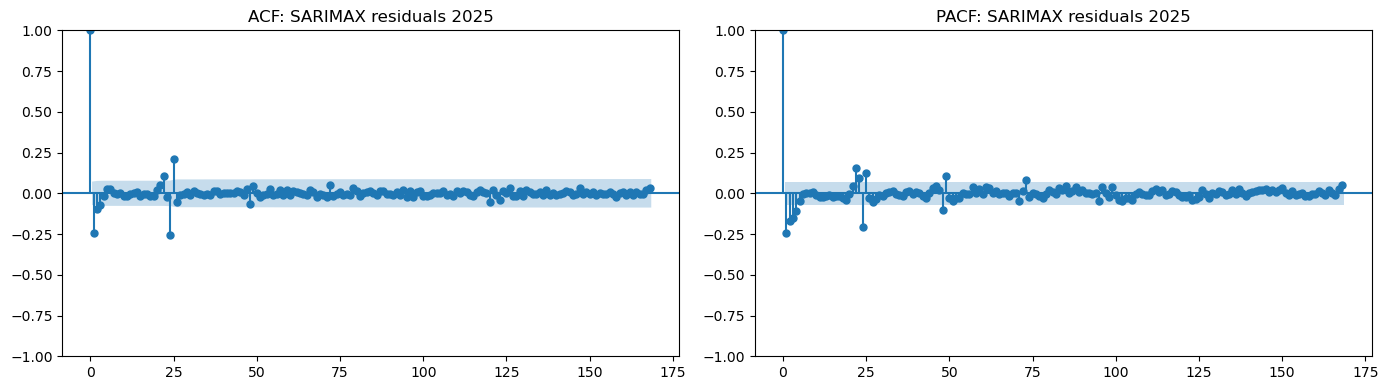

In [48]:
for year, fit in fitted_models.items():
    resid = fit.resid.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(resid, lags=168, ax=axes[0])
    axes[0].set_title(f"ACF: SARIMAX residuals {year}")

    plot_pacf(resid, lags=168, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: SARIMAX residuals {year}")

    plt.tight_layout()
    plt.show()

In [49]:
weather_features = ["temperature", "wind_speed", "weekend"]

beta_rows = []

for year, fit in fitted_models.items():
    for feature in weather_features:
        beta_rows.append({
            "year": year,
            "feature": feature,
            "beta": fit.params[feature]
        })

beta_df = pd.DataFrame(beta_rows)

beta_stats = (
    beta_df
    .groupby("feature")["beta"]
    .agg(["mean", "std"])
    .reset_index()
)

display(beta_df)
display(beta_stats)


def simulate_demand_ensemble_with_random_betas(
    fitted_models,
    X_future,
    beta_stats,
    weather_features,
    n_sims=1000,
    seed=123
):
    rng = np.random.default_rng(seed)

    years = list(fitted_models.keys())
    sims = []

    # Convert beta stats to dictionaries
    beta_mean = beta_stats.set_index("feature")["mean"].to_dict()
    beta_std = beta_stats.set_index("feature")["std"].to_dict()

    for i in range(n_sims):

        # 1. Randomly choose one historical SARIMAX model
        year = rng.choice(years)
        fit = fitted_models[year]

        # 2. Baseline forecast using the chosen model's original coefficients
        forecast = fit.get_forecast(
            steps=len(X_future),
            exog=X_future
        ).predicted_mean

        # 3. Randomly draw new weather effects
        beta_adjustment = np.zeros(len(X_future))

        for feature in weather_features:
            beta_draw = rng.normal(
                beta_mean[feature],
                beta_std[feature]
            )

            beta_original = fit.params[feature]

            # Adjustment relative to the chosen model's original beta
            beta_adjustment += (
                beta_draw - beta_original
            ) * X_future[feature].values

        # 4. Random residual noise
        resid = fit.resid.dropna()
        sigma = resid.std()

        noise = rng.normal(
            loc=0,
            scale=sigma,
            size=len(X_future)
        )

        # 5. Final simulated demand
        sim = pd.Series(
            forecast.values + beta_adjustment + noise,
            index=X_future.index,
            name=f"sim_{i+1}"
        )

        sims.append(sim)

    return pd.concat(sims, axis=1)

,year,feature,beta
0,2019,temperature,-9.540182
1,2019,wind_speed,0.695990
2,2019,weekend,-132.738154
3,2020,temperature,-6.741362
4,2020,wind_speed,-0.558688
5,2020,weekend,-108.579140
6,2021,temperature,-9.893444
7,2021,wind_speed,-0.464535
8,2021,weekend,-90.036259
9,2022,temperature,-2.508294


,feature,mean,std
0,temperature,-6.955523,2.898198
1,weekend,-100.208848,18.895595
2,wind_speed,0.029900,0.642296


In [51]:
# Prepare January 2026 exogenous variables
X_2026 = weather_series[2026][["temperature", "wind_speed"]].copy()
X_2026["weekend"] = (X_2026.index.dayofweek >= 5).astype(int)
X_2026 = X_2026[features].dropna()

demand_mc_2026 = simulate_demand_ensemble_with_random_betas(
    fitted_models=fitted_models,
    X_future=X_2026,
    beta_stats=beta_stats,
    weather_features=["temperature", "wind_speed", "weekend"],
    n_sims=100,
    seed=123
)

demand_mc_2026.head()

/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/sofietauris/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning 

,sim_1,sim_2,sim_3,sim_4,sim_5,sim_6,sim_7,sim_8,sim_9,sim_10,...,sim_91,sim_92,sim_93,sim_94,sim_95,sim_96,sim_97,sim_98,sim_99,sim_100
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,1066.116074,1017.951464,918.874297,995.410564,974.685107,895.022114,976.648902,846.102507,864.222052,979.728768,...,966.880868,1123.932723,974.604784,1036.692603,1001.888649,933.178554,895.282792,980.765250,916.226507,1077.109106
2026-01-01 01:00:00,1053.190508,880.237094,945.688796,1025.052932,1044.377602,890.563364,897.867501,869.984568,940.647888,912.728034,...,947.359135,964.794166,847.844605,1062.469528,910.765679,1034.158931,997.740397,1003.197669,1065.010356,999.174404
2026-01-01 02:00:00,991.644064,933.348771,968.023800,979.483488,1020.340473,983.476381,883.903353,795.152140,880.172397,1037.015878,...,1040.738704,1017.810255,997.915869,961.269703,983.170424,944.654716,1086.391318,951.125712,907.018877,945.694297
2026-01-01 03:00:00,1101.011739,1092.611694,982.448306,962.510001,1026.169994,968.117588,935.336248,777.872861,1040.002117,995.756823,...,1027.922900,1047.077672,1009.700532,1081.327590,1029.695416,1020.267132,1114.231371,1001.578983,970.828244,1035.073513
2026-01-01 04:00:00,1166.054450,1124.180610,1080.728016,1125.903582,1120.158569,1075.688926,1006.610518,956.665271,1100.230967,1150.924440,...,1133.456055,1085.428198,1208.304029,1103.038870,1049.494512,996.463207,1172.207276,1157.152404,1012.119625,1111.014927


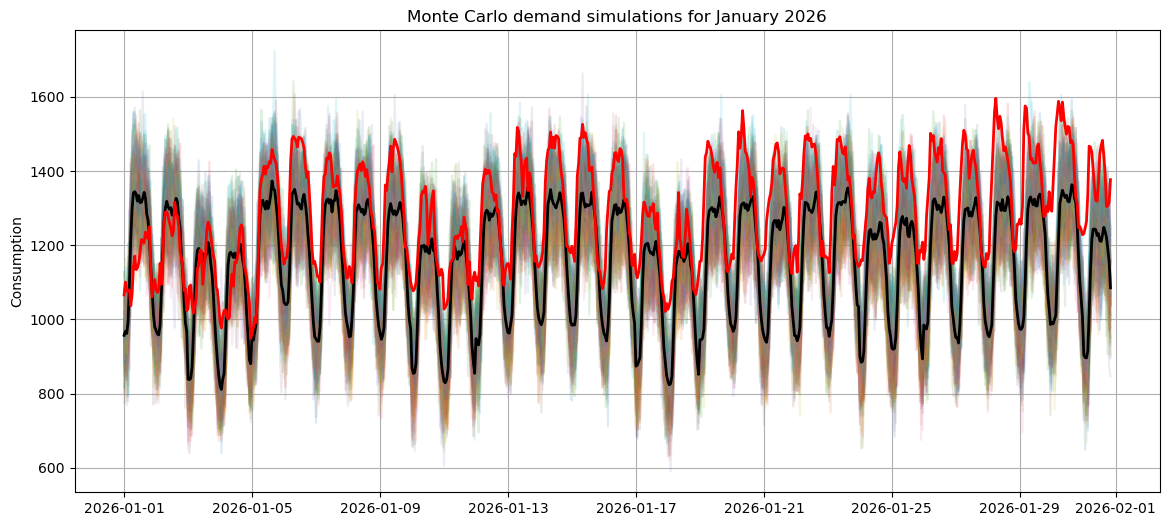

In [52]:
plt.figure(figsize=(14, 6))

plt.plot(demand_mc_2026.index[:741], demand_mc_2026.iloc[:741, :], alpha=0.15)
plt.plot(demand_mc_2026.index[:741], demand_mc_2026.mean(axis=1)[:741], color="black", linewidth=2)
plt.plot(demand_mc_2026.index[:741], demand_series[2026].values, color="red", linewidth=2)

plt.title("Monte Carlo demand simulations for January 2026")
plt.ylabel("Consumption")
plt.grid(True)
plt.show()